In [32]:
# Step: Import ML libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap.umap_ as umap

In [33]:
# Step: Code cell
echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0)
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0)
real_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/mean_vector_real_echo.csv", index_col=0)

echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(echo_df.columns)]
real_echo_df = real_echo_df[sorted(echo_df.columns)]

In [34]:
# Step: Code cell
non_echo_df.index

Index(['output_AskReddit.csv', 'output_Bible.csv', 'output_books.csv',
       'output_changemyview.csv', 'output_CulinaryPlating.csv',
       'output_explainlikeimfive.csv', 'output_OutOfTheLoop.csv',
       'output_philosophy.csv', 'output_science.csv', 'output_shakespeare.csv',
       'output_skeptic.csv', 'output_sports.csv', 'output_todayilearned.csv',
       'output_TrueOffMyChest.csv', 'output_TrueReddit.csv'],
      dtype='object', name='file_name')

In [35]:
# Step: Code cell
echo_df['source'] = 'echo'
non_echo_df['source'] = 'non_echo'
real_echo_df['source'] = 'real_echo'

full_df = pd.concat([echo_df, non_echo_df, real_echo_df])

In [36]:
# Step: Code cell
subreddit_name = list(full_df['source'].keys())
real_label = full_df['source']
data = full_df.drop(columns=['source','neutral'])

In [37]:
# Step: Preprocess / scale features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(data_scaled)
real_label = full_df["source"]
numeric_real_label = [
    0 if x == "echo" else
    2 if x == "real_echo" else
    1
    for x in real_label
]


/Users/luigilomasto/.local/share/virtualenvs/EC2Vec_experiments-hnE7iqgF/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/luigilomasto/.local/share/virtualenvs/EC2Vec_experiments-hnE7iqgF/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


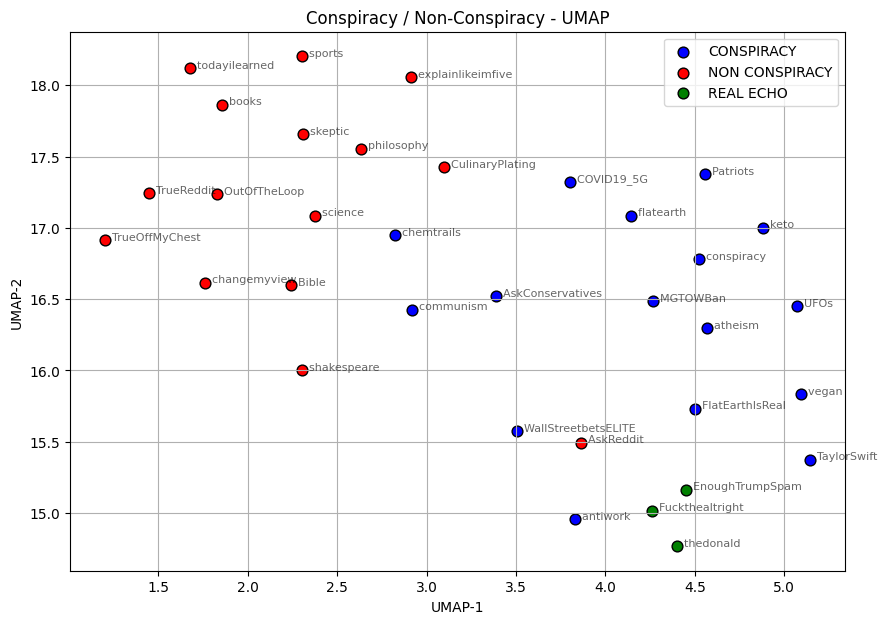

In [38]:
# Step: Visualization
import matplotlib.pyplot as plt
import numpy as np

marker_map = {0: 'o', 1: 's'}  # 0 = cerchio, 1 = quadrato
color_map = {0: 'blue', 1: 'red', 2: 'green'}  # 0 = blue, 1 = red

plt.figure(figsize=(10, 7))

for real in np.unique(numeric_real_label):
    idx = np.where(numeric_real_label == real)[0]
    if real == 1:
        text_real = "NON CONSPIRACY"
    elif real == 2:
        text_real = "REAL ECHO"
    else:
        text_real = "CONSPIRACY"
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        c=color_map[real],
        marker='o',
        edgecolor='k',
        s=60,
        label=f"{text_real}"
    )

for i, txt in enumerate(full_df.index):
    plt.annotate(
        txt.replace("reddit_filteredData_", "").replace(".csv", "").replace("output_", "  "),
        (embedding[i, 0], embedding[i, 1]),
        fontsize=8,
        alpha=0.6
    )

plt.title("Conspiracy / Non-Conspiracy - UMAP")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.legend()
plt.show()


In [39]:
# Step: Code cell
full_df = pd.concat([echo_df, non_echo_df])
subreddit_name = list(full_df['source'].keys())
real_label = full_df['source']
data = full_df.drop(columns=['source','neutral'])#.fillna(0)

In [40]:
# Step: Preprocess / scale features
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(data_scaled)

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(data_scaled)
real_label = full_df["source"]
print(clusters)

real_echo_df_scaled = scaler.transform(real_echo_df.drop(columns=['source','neutral']))
clusters_re = kmeans.predict(real_echo_df_scaled)
print(clusters_re)


numeric_real_label = [
    0 if x == "echo" else
    2 if x == "real_echo" else
    1
    for x in real_label
]

for i in range(len(clusters)):
    print(str(subreddit_name[i])+" -- Real: "+str(numeric_real_label[i])+" -- Predicted: "+str(clusters[i]))

[0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[0 0 0]
output_antiwork.csv -- Real: 0 -- Predicted: 0
output_AskConservatives.csv -- Real: 0 -- Predicted: 0
output_atheism.csv -- Real: 0 -- Predicted: 0
output_chemtrails.csv -- Real: 0 -- Predicted: 1
output_communism.csv -- Real: 0 -- Predicted: 1
output_conspiracy.csv -- Real: 0 -- Predicted: 0
output_COVID19_5G.csv -- Real: 0 -- Predicted: 0
output_flatearth.csv -- Real: 0 -- Predicted: 0
output_FlatEarthIsReal.csv -- Real: 0 -- Predicted: 0
output_keto.csv -- Real: 0 -- Predicted: 0
output_MGTOWBan.csv -- Real: 0 -- Predicted: 0
output_Patriots.csv -- Real: 0 -- Predicted: 0
output_TaylorSwift.csv -- Real: 0 -- Predicted: 0
output_UFOs.csv -- Real: 0 -- Predicted: 0
output_vegan.csv -- Real: 0 -- Predicted: 0
output_WallStreetbetsELITE.csv -- Real: 0 -- Predicted: 1
output_AskReddit.csv -- Real: 1 -- Predicted: 0
output_Bible.csv -- Real: 1 -- Predicted: 1
output_books.csv -- Real: 1 -- Predicted: 1
output_changemy

/Users/luigilomasto/.local/share/virtualenvs/EC2Vec_experiments-hnE7iqgF/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


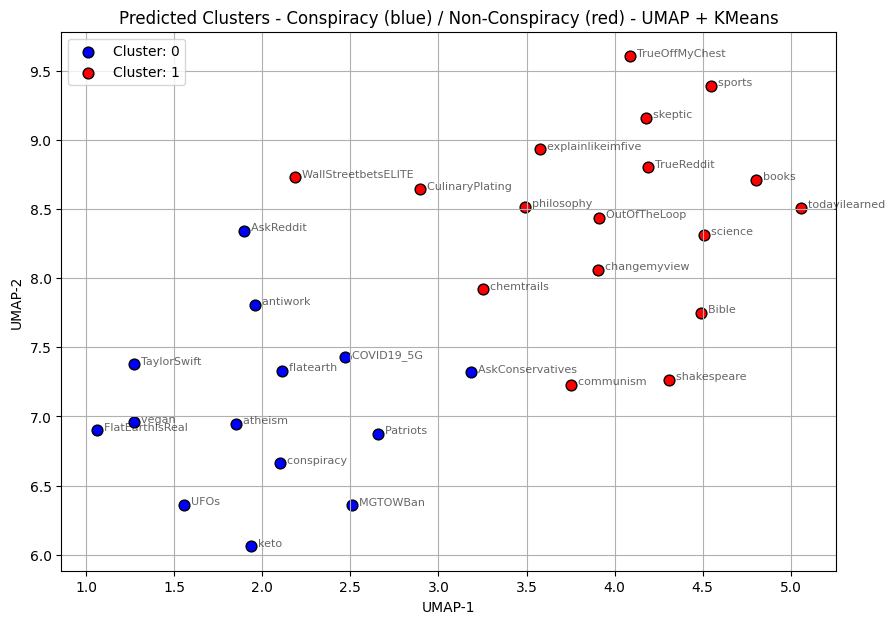

In [41]:
# Step: Clustering with KMeans
import matplotlib.pyplot as plt
import numpy as np

marker_map = {0: 'o', 1: 's'}  # opzionale: puoi usare lo stesso marker per tutti se non ti serve
color_map = {0: 'blue', 1: 'red'}

plt.figure(figsize=(10, 7))

for pred in np.unique(clusters):
    idx = np.where(clusters == pred)[0]
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        c=color_map[pred],
        marker='o',  # oppure marker_map[pred] se vuoi marker diversi
        edgecolor='k',
        s=60,
        label=f"Cluster: {pred}"
    )

for i, txt in enumerate(full_df.index):
    plt.annotate(
        txt.replace("reddit_filteredData_", "").replace(".csv", "").replace("output_", "  "),
        (embedding[i, 0], embedding[i, 1]),
        fontsize=8,
        alpha=0.6
    )

plt.title("Predicted Clusters - Conspiracy (blue) / Non-Conspiracy (red) - UMAP + KMeans")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.legend()
plt.show()


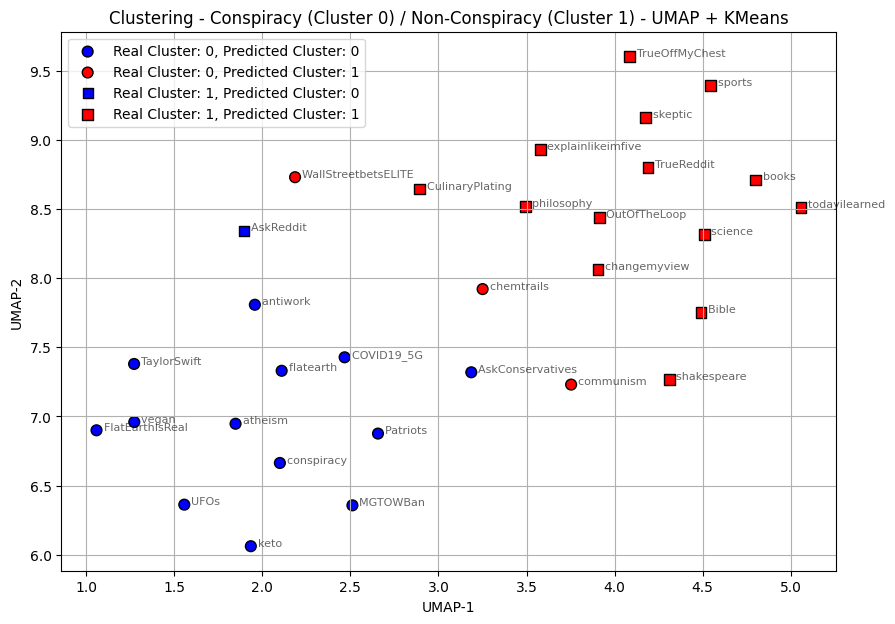

In [42]:
# Step: Clustering with KMeans
import matplotlib.pyplot as plt
import numpy as np


marker_map = {0: 'o', 1: 's'}  # 0 = cerchio, 1 = quadrato

color_map = {0: 'blue', 1: 'red'}

plt.figure(figsize=(10, 7))

for real in np.unique(numeric_real_label):
    for pred in np.unique(clusters):
        idx = np.where((numeric_real_label == real) & (clusters == pred))[0]
        plt.scatter(
            embedding[idx, 0],
            embedding[idx, 1],
            c=[color_map[p] for p in clusters[idx]],
            marker=marker_map[real],
            edgecolor='k',
            s=60,
            label=f"Real Cluster: {real}, Predicted Cluster: {pred}"
        )

for i, txt in enumerate(full_df.index):
    plt.annotate(
        txt.replace("reddit_filteredData_", "").replace(".csv", "").replace("output_", "  "),
        (embedding[i, 0], embedding[i, 1]),
        fontsize=8,
        alpha=0.6
    )

plt.title("Clustering - Conspiracy (Cluster 0) / Non-Conspiracy (Cluster 1) - UMAP + KMeans")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.legend()
plt.show()

# Section

LOGISTIC REGRESSION Cross Validation K-fold leave one out

In [43]:
# Step: Load and inspect data
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import classification_report, accuracy_score

echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0).drop(columns=['neutral'])
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0).drop(columns=['neutral'])

echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(non_echo_df.columns)]

echo_df["label"] = 1
non_echo_df["label"] = 0

df = pd.concat([echo_df, non_echo_df])
X = df.drop(columns=["label"]).values
y = df["label"].values

loo = LeaveOneOut()
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    y_true.append(y_test[0])
    y_pred.append(pred[0])

print("Accuracy (LOOCV):", accuracy_score(y_true, y_pred))
print("\nClassification Report (LOOCV):\n", classification_report(y_true, y_pred))


Accuracy (LOOCV): 0.9032258064516129

Classification Report (LOOCV):
               precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       0.88      0.94      0.91        16

    accuracy                           0.90        31
   macro avg       0.91      0.90      0.90        31
weighted avg       0.90      0.90      0.90        31



Stratified 80/20 -> test C0: 3/16, test C1: 3/15 (tot test=6)
Stratified splits evaluated: 1000
Overall — Acc(mean)=0.874, Prec(macro)=0.904, Rec(macro)=0.874, F1(macro)=0.870
C0 — Acc=0.830, Prec=0.937, Rec=0.830, F1=0.863
C1 — Acc=0.917, Prec=0.871, Rec=0.917, F1=0.877


/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_67635/56915204.py:109: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],


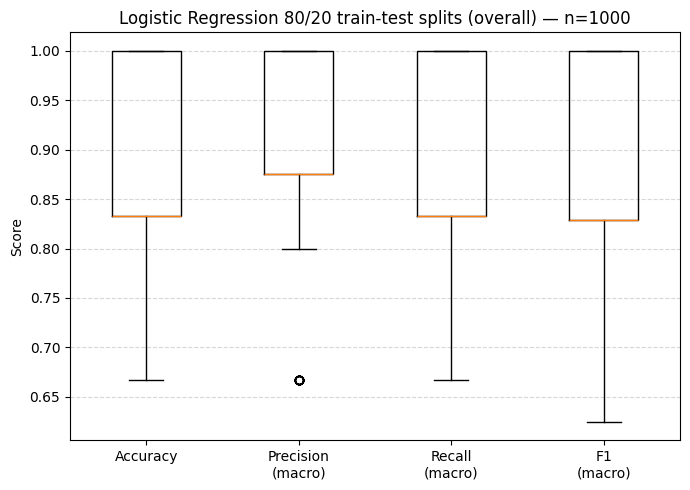

/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_67635/56915204.py:118: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


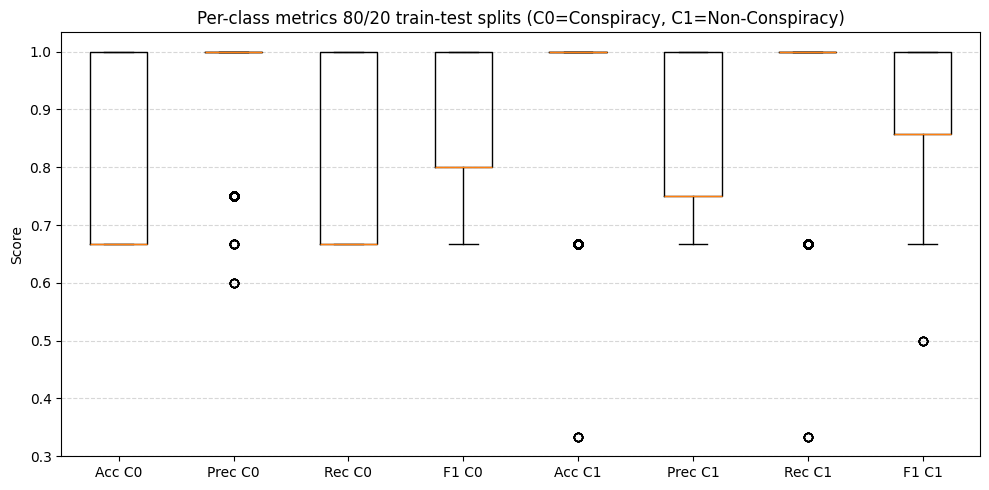

In [44]:
# Step: Load and inspect data
import pandas as pd
import numpy as np
import itertools, random
from math import floor
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support
)

ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv"
NON_ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv"
REMOVE_COL = "neutral"
TEST_RATIO = 0.20
MAX_SPLITS = 1000          # None per TUTTE le combinazioni (potrebbero essere tantissime)
RANDOM_SEED = 42

echo_df = pd.read_csv(ECHO_PATH, index_col=0)
non_echo_df = pd.read_csv(NON_ECHO_PATH, index_col=0)

for df_ in (echo_df, non_echo_df):
    if REMOVE_COL in df_.columns:
        df_.drop(columns=[REMOVE_COL], inplace=True)

cols_sorted = sorted(set(echo_df.columns) & set(non_echo_df.columns))
echo_df = echo_df[cols_sorted].copy()
non_echo_df = non_echo_df[cols_sorted].copy()

echo_df["label"] = 0  # C0 = CONSPIRACY
non_echo_df["label"] = 1  # C1 = NON_CONSPIRACY

df = pd.concat([echo_df, non_echo_df], axis=0)
X = df.drop(columns=["label"]).to_numpy(dtype=float)
y = df["label"].to_numpy()

idx_c0 = np.where(y == 0)[0]
idx_c1 = np.where(y == 1)[0]
n0, n1 = len(idx_c0), len(idx_c1)

t0 = max(1, int(round(TEST_RATIO * n0)))
t1 = max(1, int(round(TEST_RATIO * n1)))
t0 = min(t0, n0 - 1)
t1 = min(t1, n1 - 1)

print(f"Stratified 80/20 -> test C0: {t0}/{n0}, test C1: {t1}/{n1} (tot test={t0+t1})")

comb_c0 = list(itertools.combinations(idx_c0, t0))
comb_c1 = list(itertools.combinations(idx_c1, t1))

random.Random(RANDOM_SEED).shuffle(comb_c0)
random.Random(RANDOM_SEED + 1).shuffle(comb_c1)

prod_iter = itertools.product(comb_c0, comb_c1)
if MAX_SPLITS is not None:
    prod_iter = itertools.islice(prod_iter, MAX_SPLITS)

model_tpl = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=RANDOM_SEED, max_iter=2000)
)

acc_list = []
prec_macro_list, rec_macro_list, f1_macro_list = [], [], []

acc_c0_list, acc_c1_list = [], []
prec_c0_list, prec_c1_list = [], []
rec_c0_list, rec_c1_list = [], []
f1_c0_list, f1_c1_list = [], []

n_splits = 0
for test_c0, test_c1 in prod_iter:
    n_splits += 1
    test_idx = np.array(list(test_c0) + list(test_c1))
    train_mask = np.ones(len(y), dtype=bool)
    train_mask[test_idx] = False

    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]

    model = model_tpl
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))
    prec_macro_list.append(precision_score(y_test, y_pred, average="macro", zero_division=0))
    rec_macro_list.append(recall_score(y_test, y_pred, average="macro", zero_division=0))
    f1_macro_list.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1], zero_division=0)
    prec_c0_list.append(p[0]); prec_c1_list.append(p[1])
    rec_c0_list.append(r[0]);  rec_c1_list.append(r[1])
    f1_c0_list.append(f[0]);   f1_c1_list.append(f[1])
    acc_c0_list.append(r[0]);  acc_c1_list.append(r[1])

print(f"Stratified splits evaluated: {n_splits}")
print(f"Overall — Acc(mean)={np.mean(acc_list):.3f}, Prec(macro)={np.mean(prec_macro_list):.3f}, "
      f"Rec(macro)={np.mean(rec_macro_list):.3f}, F1(macro)={np.mean(f1_macro_list):.3f}")
print(f"C0 — Acc={np.mean(acc_c0_list):.3f}, Prec={np.mean(prec_c0_list):.3f}, "
      f"Rec={np.mean(rec_c0_list):.3f}, F1={np.mean(f1_c0_list):.3f}")
print(f"C1 — Acc={np.mean(acc_c1_list):.3f}, Prec={np.mean(prec_c1_list):.3f}, "
      f"Rec={np.mean(rec_c1_list):.3f}, F1={np.mean(f1_c1_list):.3f}")

plt.figure(figsize=(7,5))
plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],
            labels=["Accuracy", "Precision\n(macro)", "Recall\n(macro)", "F1\n(macro)"])
plt.ylabel("Score")
plt.title(f"Logistic Regression 80/20 train-test splits (overall) — n={n_splits}")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.boxplot([
    acc_c0_list, prec_c0_list, rec_c0_list, f1_c0_list,
    acc_c1_list, prec_c1_list, rec_c1_list, f1_c1_list
], labels=[
    "Acc C0", "Prec C0", "Rec C0", "F1 C0",
    "Acc C1", "Prec C1", "Rec C1", "F1 C1"
])
plt.ylabel("Score")
plt.title("Per-class metrics 80/20 train-test splits (C0=Conspiracy, C1=Non-Conspiracy)")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Section

MLP Cross Validation leave one out

In [45]:
# Step: Load and inspect data
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0).drop(columns=['neutral'])
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0).drop(columns=['neutral'])

echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(non_echo_df.columns)]

echo_df["label"] = 1
non_echo_df["label"] = 0

df = pd.concat([echo_df, non_echo_df])
X = df.drop(columns=["label"]).values
y = df["label"].values

loo = LeaveOneOut()
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam', random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    y_true.append(y_test[0])
    y_pred.append(pred[0])

print("Accuracy (LOOCV - MLP):", accuracy_score(y_true, y_pred))
print("\nClassification Report (LOOCV - MLP):\n", classification_report(y_true, y_pred))


Accuracy (LOOCV - MLP): 0.9032258064516129

Classification Report (LOOCV - MLP):
               precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.93      0.88      0.90        16

    accuracy                           0.90        31
   macro avg       0.90      0.90      0.90        31
weighted avg       0.91      0.90      0.90        31



Stratified 80/20 -> test C0: 3/16, test C1: 3/15 (tot test=6)
Stratified splits evaluated: 1000
Overall — Acc(mean)=0.785, Prec(macro)=0.811, Rec(macro)=0.785, F1(macro)=0.782
C0 — Acc=0.703, Prec=0.876, Rec=0.703, F1=0.769
C1 — Acc=0.867, Prec=0.746, Rec=0.867, F1=0.794


/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_67635/2955095897.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],


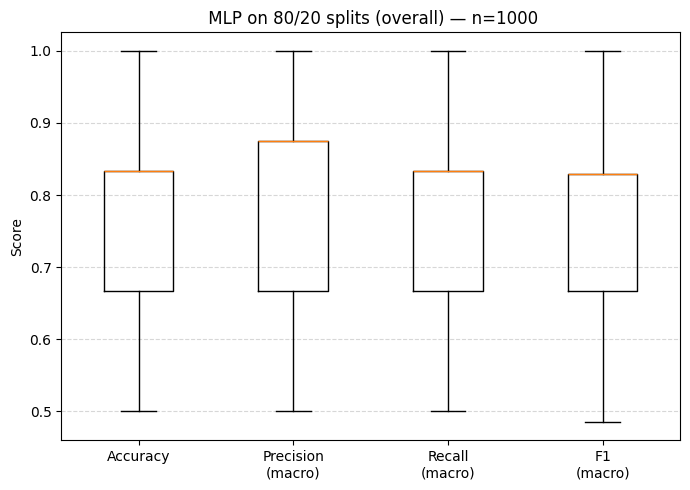

/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_67635/2955095897.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


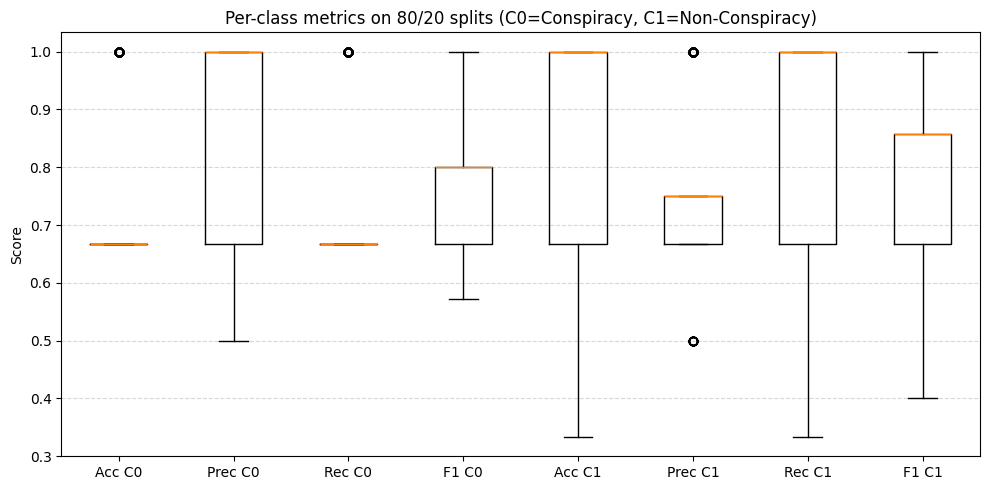

In [51]:
# Step: Load and inspect data
import pandas as pd
import numpy as np
import itertools, random
from math import floor
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_fscore_support
)

ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv"
NON_ECHO_PATH = "Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv"
REMOVE_COL = "neutral"
TEST_RATIO = 0.20
MAX_SPLITS = 1000          # None per tutte le combinazioni (può essere enorme)
RANDOM_SEED = 42

echo_df = pd.read_csv(ECHO_PATH, index_col=0)
non_echo_df = pd.read_csv(NON_ECHO_PATH, index_col=0)

for df_ in (echo_df, non_echo_df):
    if REMOVE_COL in df_.columns:
        df_.drop(columns=[REMOVE_COL], inplace=True)

cols_sorted = sorted(set(echo_df.columns) & set(non_echo_df.columns))
echo_df = echo_df[cols_sorted].copy()
non_echo_df = non_echo_df[cols_sorted].copy()

echo_df["label"] = 0  # C0 = CONSPIRACY
non_echo_df["label"] = 1  # C1 = NON_CONSPIRACY

df = pd.concat([echo_df, non_echo_df], axis=0)
X = df.drop(columns=["label"]).to_numpy(dtype=float)
y = df["label"].to_numpy()

idx_c0 = np.where(y == 0)[0]
idx_c1 = np.where(y == 1)[0]
n0, n1 = len(idx_c0), len(idx_c1)

t0 = max(1, int(round(TEST_RATIO * n0)))
t1 = max(1, int(round(TEST_RATIO * n1)))
t0 = min(t0, n0 - 1)
t1 = min(t1, n1 - 1)

print(f"Stratified 80/20 -> test C0: {t0}/{n0}, test C1: {t1}/{n1} (tot test={t0+t1})")

comb_c0 = list(itertools.combinations(idx_c0, t0))
comb_c1 = list(itertools.combinations(idx_c1, t1))

random.Random(RANDOM_SEED).shuffle(comb_c0)
random.Random(RANDOM_SEED + 1).shuffle(comb_c1)

prod_iter = itertools.product(comb_c0, comb_c1)

if MAX_SPLITS is not None:
    prod_iter = itertools.islice(prod_iter, MAX_SPLITS)

model_tpl = make_pipeline(StandardScaler(),MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', random_state=42, max_iter=1000))

acc_list = []
prec_macro_list, rec_macro_list, f1_macro_list = [], [], []

acc_c0_list, acc_c1_list = [], []
prec_c0_list, prec_c1_list = [], []
rec_c0_list, rec_c1_list = [], []
f1_c0_list, f1_c1_list = [], []

n_splits = 0
for test_c0, test_c1 in prod_iter:
    n_splits += 1
    test_idx = np.array(list(test_c0) + list(test_c1))
    train_mask = np.ones(len(y), dtype=bool)
    train_mask[test_idx] = False

    X_train, X_test = X[train_mask], X[~train_mask]
    y_train, y_test = y[train_mask], y[~train_mask]

    model = model_tpl  # nuova istanza non necessaria in pipeline standard
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc_list.append(accuracy_score(y_test, y_pred))
    prec_macro_list.append(precision_score(y_test, y_pred, average="macro", zero_division=0))
    rec_macro_list.append(recall_score(y_test, y_pred, average="macro", zero_division=0))
    f1_macro_list.append(f1_score(y_test, y_pred, average="macro", zero_division=0))

    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1], zero_division=0)
    prec_c0_list.append(p[0]); prec_c1_list.append(p[1])
    rec_c0_list.append(r[0]);  rec_c1_list.append(r[1])
    f1_c0_list.append(f[0]);   f1_c1_list.append(f[1])
    acc_c0_list.append(r[0]);  acc_c1_list.append(r[1])

print(f"Stratified splits evaluated: {n_splits}")
print(f"Overall — Acc(mean)={np.mean(acc_list):.3f}, Prec(macro)={np.mean(prec_macro_list):.3f}, "
      f"Rec(macro)={np.mean(rec_macro_list):.3f}, F1(macro)={np.mean(f1_macro_list):.3f}")
print(f"C0 — Acc={np.mean(acc_c0_list):.3f}, Prec={np.mean(prec_c0_list):.3f}, "
      f"Rec={np.mean(rec_c0_list):.3f}, F1={np.mean(f1_c0_list):.3f}")
print(f"C1 — Acc={np.mean(acc_c1_list):.3f}, Prec={np.mean(prec_c1_list):.3f}, "
      f"Rec={np.mean(rec_c1_list):.3f}, F1={np.mean(f1_c1_list):.3f}")

plt.figure(figsize=(7,5))
plt.boxplot([acc_list, prec_macro_list, rec_macro_list, f1_macro_list],
            labels=["Accuracy", "Precision\n(macro)", "Recall\n(macro)", "F1\n(macro)"])
plt.ylabel("Score")
plt.title(f" MLP on 80/20 splits (overall) — n={n_splits}")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.boxplot([
    acc_c0_list, prec_c0_list, rec_c0_list, f1_c0_list,
    acc_c1_list, prec_c1_list, rec_c1_list, f1_c1_list
], labels=[
    "Acc C0", "Prec C0", "Rec C0", "F1 C0",
    "Acc C1", "Prec C1", "Rec C1", "F1 C1"
])
plt.ylabel("Score")
plt.title("Per-class metrics on 80/20 splits (C0=Conspiracy, C1=Non-Conspiracy)")
plt.grid(True, axis='y', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# Section

Logistic and MLP all dataset to classify REC

Logistic Regression

In [48]:
# Step: Load and inspect data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv", index_col=0).drop(columns=['neutral'])
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv", index_col=0).drop(columns=['neutral'])


echo_df = echo_df[sorted(echo_df.columns)]
non_echo_df = non_echo_df[sorted(non_echo_df.columns)]


echo_df["label"] = 0
non_echo_df["label"] = 1

df = pd.concat([echo_df, non_echo_df])
X = df.drop(columns=["label"])
y = df["label"]


model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X, y)

real_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/mean_vector_real_echo.csv", index_col=0).drop(columns=['neutral']).fillna(0)
real_echo_df = real_echo_df[sorted(real_echo_df.columns)]

y_pred = model.predict_proba(real_echo_df)
print(y_pred)


[[0.53501326 0.46498674]
 [0.53294557 0.46705443]
 [0.53380592 0.46619408]]




Multi Layer Perceptron

In [49]:
# Step: Load and inspect data
import pandas as pd
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', random_state=42, max_iter=1000)
mlp.fit(X, y)

real_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/mean_vector_real_echo.csv", index_col=0).drop(columns=['neutral']).fillna(0)
real_echo_df = real_echo_df[sorted(real_echo_df.columns)]

y_pred = mlp.predict_proba(real_echo_df)
print(y_pred)


[[0.66120544 0.33879456]
 [0.8187138  0.1812862 ]
 [0.77913382 0.22086618]]


In [ ]:
# Step: Code cell


# Section
<h1> LDA </h1>

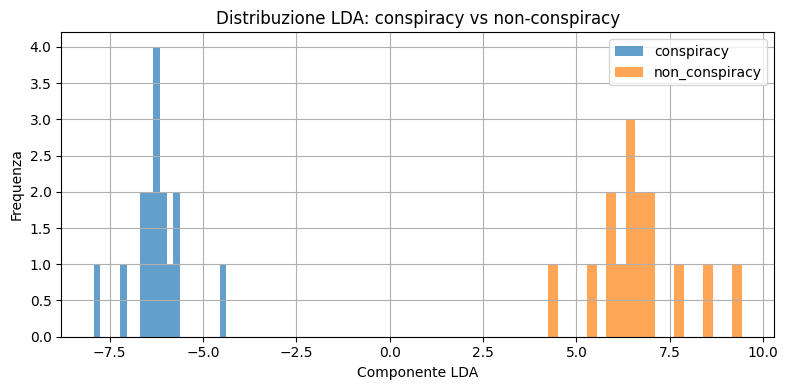

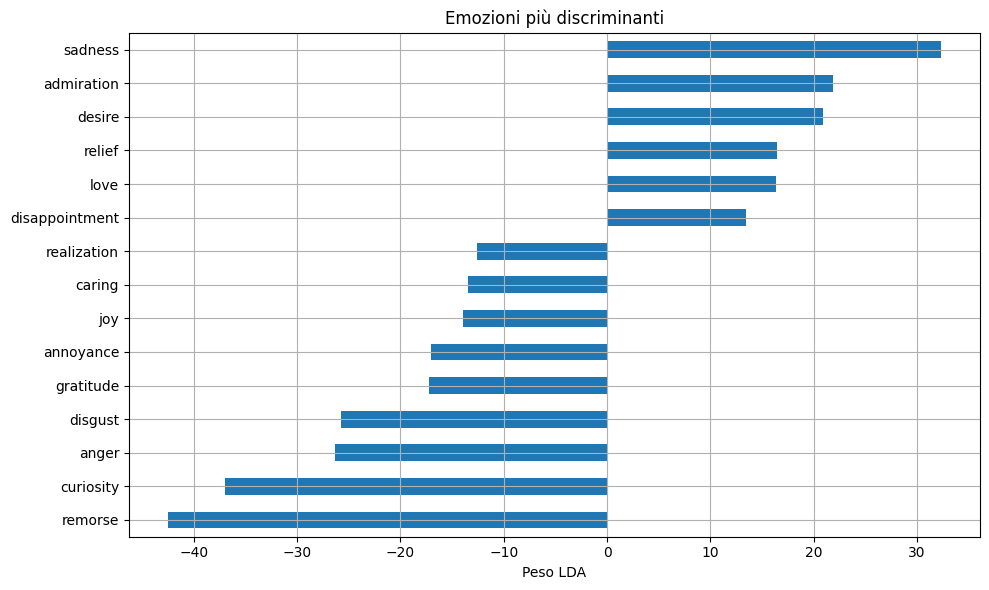

In [50]:
# Step: Load and inspect data
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt

echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_echo.csv")
non_echo_df = pd.read_csv("Delivery/3_Outputs/3.2_Mean_Vector/meanVector_non_echo.csv")

echo_df["label"] = "conspiracy"
non_echo_df["label"] = "non_conspiracy"


df = pd.concat([echo_df, non_echo_df], ignore_index=True)


X = df.drop(columns=["file_name", "label", "neutral"])
y = df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure(figsize=(8, 4))
plt.hist(X_lda[y == "conspiracy"], bins=20, alpha=0.7, label="conspiracy")
plt.hist(X_lda[y == "non_conspiracy"], bins=20, alpha=0.7, label="non_conspiracy")
plt.title("Distribuzione LDA: conspiracy vs non-conspiracy")
plt.xlabel("Componente LDA")
plt.ylabel("Frequenza")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

lda_coefficients = pd.Series(lda.coef_[0], index=X.columns)
lda_coefficients_sorted = lda_coefficients.abs().sort_values(ascending=False)

top_emotions = lda_coefficients_sorted.head(15).index
lda_coefficients[top_emotions].sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Emozioni più discriminanti")
plt.xlabel("Peso LDA")
plt.tight_layout()
plt.grid(True)
plt.show()
